# Pneumonia Classification with NNs
**Computer Vision | Assignment 2**

Goal: Maximize classification accuracy, precision and recall on the chest X-ray dataset (BACTERIAL / NORMAL / VIRAL).

## 1. Imports & Configuration

In [2]:
import time
import numpy as np
import tensorflow as tf
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Rescaling, RandomFlip, RandomRotation, \
    RandomZoom, GlobalAveragePooling2D
from sklearn.utils.class_weight import compute_class_weight
from keras.optimizers import Adam
import os
from dotenv import load_dotenv
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import keras_tuner as kt

# loads .env (paths to images)
load_dotenv()

TRAIN_DIR = os.getenv('TRAIN_DIR')
TEST_DIR = os.getenv('TEST_DIR')

assert TRAIN_DIR and TEST_DIR, 'Set TRAIN_DIR and TEST_DIR in your .env file'  # ensure env variables are loaded

# config
BATCH_SIZE = 12
EPOCHS = 8
IMG_HEIGHT = 128
IMG_WIDTH = 128
IMG_CHANNELS = 3
SEED = 123

## 2. Load Datasets

In [4]:
# create training, validation and test datasets
train_ds, val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    seed=SEED,
    validation_split=0.2,
    subset='both',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    labels='inferred',
    shuffle=True
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    seed=None,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    labels='inferred',
    shuffle=True
)

class_names = train_ds.class_names
num_classes = len(class_names)
print('Classes:', class_names)
# print('Num classes:', num_classes)

Found 5419 files belonging to 3 classes.
Using 4336 files for training.
Using 1083 files for validation.
Found 437 files belonging to 3 classes.
Classes: ['BACTERIAL', 'NORMAL', 'VIRAL']


## 2.1 Class weights

In [5]:
# Extract all training labels to compute class weights
# all_labels = np.concatenate([labels.numpy() for _, labels in train_ds])
# weights = compute_class_weight('balanced', classes=np.unique(all_labels), y=all_labels)
# class_weights = dict(enumerate(weights))

# focus on recall
class_weights = {0: 1, 1: 0.7, 2: 2.5}
# class_weights = {0: 1.5, 1: 0.75, 2: 2.75}

print('Class weights:', class_weights)

Class weights: {0: 1, 1: 0.7, 2: 2.5}


## 3. Dataset Distribution (Q2 - Is the dataset balanced?)

Training set distribution:
  BACTERIAL: 2596 images
  NORMAL: 1461 images
  VIRAL: 1363 images
  Total: 5420

Test set distribution:
  BACTERIAL: 184 images
  NORMAL: 122 images
  VIRAL: 132 images
  Total: 438


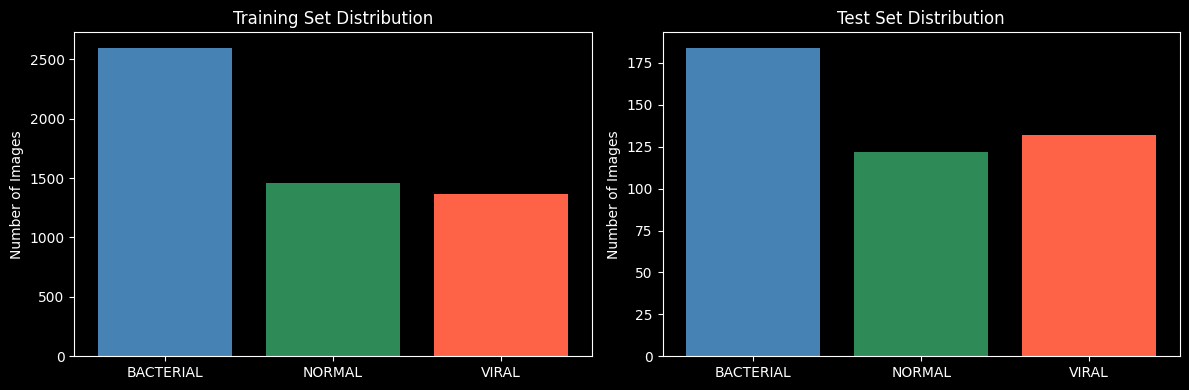

In [6]:
def count_images(directory):
    counts = {}
    for cls in sorted(os.listdir(directory)):
        cls_path = os.path.join(directory, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts


train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

print('Training set distribution:')
for cls, count in train_counts.items():
    print(f'  {cls}: {count} images')
print(f'  Total: {sum(train_counts.values())}')

print('\nTest set distribution:')
for cls, count in test_counts.items():
    print(f'  {cls}: {count} images')
print(f'  Total: {sum(test_counts.values())}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(train_counts.keys(), train_counts.values(), color=['steelblue', 'seagreen', 'tomato'])
axes[0].set_title('Training Set Distribution')
axes[0].set_ylabel('Number of Images')
axes[1].bar(test_counts.keys(), test_counts.values(), color=['steelblue', 'seagreen', 'tomato'])
axes[1].set_title('Test Set Distribution')
axes[1].set_ylabel('Number of Images')
plt.tight_layout()
plt.show()

## 4. Visualise Sample Images

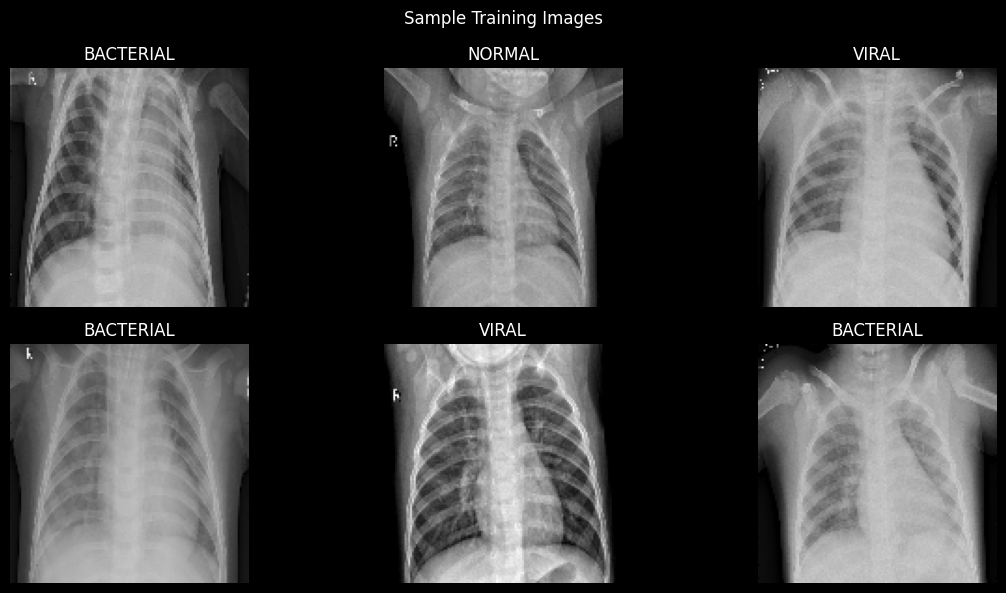

In [7]:
plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(2):
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i].numpy()])
        plt.axis('off')
plt.suptitle('Sample Training Images')
plt.tight_layout()
plt.show()

## 5. Baseline Model

In [8]:
model = tf.keras.models.Sequential([

    # RandomFlip('horizontal'),
    # RandomRotation(0.1),
    # RandomZoom(0.1),
    # Rescaling(1.0 / 255),

    Rescaling(1.0 / 255),
    Conv2D(16, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    MaxPooling2D(2, 2),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy'],
)

# model.summary() # model summary visualization

/Users/akodini/college-projects/cv-assign2-ann/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 6. Train the Baseline Model (Q1 - How long does it take to train?)

In [9]:
save_callback = tf.keras.callbacks.ModelCheckpoint(
    'pneumonia_baseline.keras',
    save_freq='epoch',
    save_best_only=True
)

start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    # class_weight=class_weights,
    callbacks=[save_callback],
    epochs=EPOCHS
)

elapsed = time.time() - start_time
print(f'\nTraining time: {elapsed:.1f} seconds ({elapsed / 60:.1f} minutes)')

Epoch 1/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.7207 - loss: 0.6516 - val_accuracy: 0.7710 - val_loss: 0.5442
Epoch 2/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.7883 - loss: 0.5059 - val_accuracy: 0.7747 - val_loss: 0.5361
Epoch 3/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.8054 - loss: 0.4743 - val_accuracy: 0.7793 - val_loss: 0.5155
Epoch 4/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.8173 - loss: 0.4329 - val_accuracy: 0.7775 - val_loss: 0.5121
Epoch 5/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.8358 - loss: 0.3979 - val_accuracy: 0.7710 - val_loss: 0.5490
Epoch 6/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.8478 - loss: 0.3541 - val_accuracy: 0.7987 - val_loss: 0.5354
Epoch 7/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.8727 - loss: 0.3057 - val_accuracy: 0.7895 - val_loss: 0.5939
Epoch 8/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.8877 - loss: 0.2604 - val_accu

## 7. Evaluate on Test Set

In [10]:
score = model.evaluate(test_ds)
print(f'Test loss:     {score[0]:.4f}')
print(f'Test accuracy: {score[1]:.4f}')

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7895 - loss: 0.6200
Test loss:     0.6200
Test accuracy: 0.7895


## 8. Training Curves (Q3 - Is the network overfitting?)

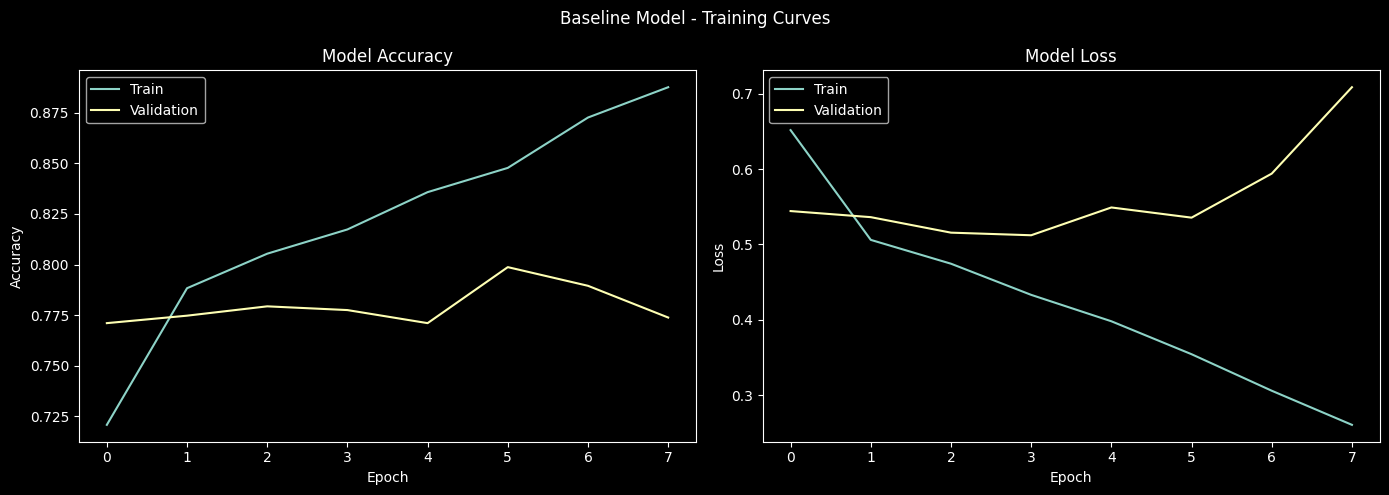

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Baseline Model - Training Curves')
plt.tight_layout()
plt.show()

## 9. Sample Predictions on Test Set

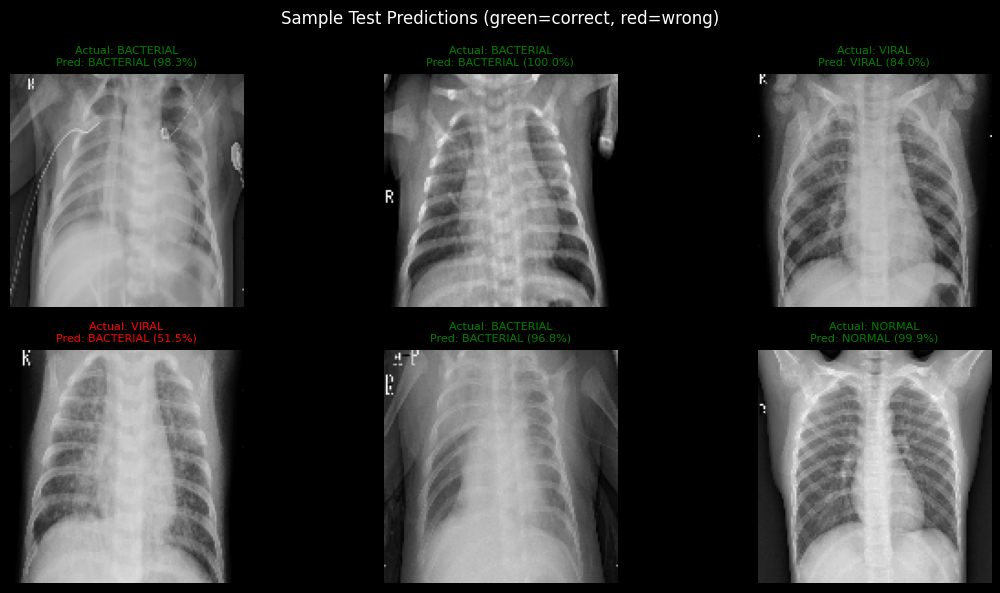

In [12]:
plt.figure(figsize=(12, 6))
for images, labels in test_ds.take(1):
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        prediction = model.predict(tf.expand_dims(images[i].numpy(), 0), verbose=0)
        actual = class_names[labels[i].numpy()]
        predicted = class_names[np.argmax(prediction)]
        confidence = 100 * np.max(prediction)
        color = 'green' if actual == predicted else 'red'
        plt.title(f'Actual: {actual}\nPred: {predicted} ({confidence:.1f}%)', color=color, fontsize=8)
        plt.axis('off')
plt.suptitle('Sample Test Predictions (green=correct, red=wrong)')
plt.tight_layout()
plt.show()

## 10. Per-Class Metrics (Q7 - Precision, Recall & F1)

Accuracy alone is misleading on imbalanced data. Per-class metrics show how well the model handles each class individually.

              precision    recall  f1-score   support

   BACTERIAL       0.74      0.84      0.79       184
      NORMAL       0.92      0.93      0.92       122
       VIRAL       0.74      0.59      0.66       131

    accuracy                           0.79       437
   macro avg       0.80      0.79      0.79       437
weighted avg       0.79      0.79      0.79       437



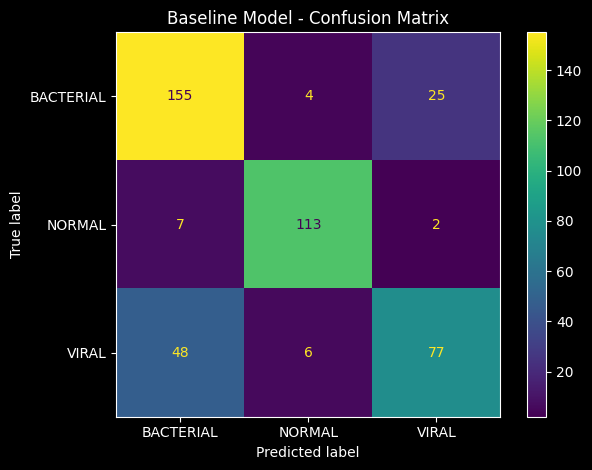

In [13]:
# collect all predictions and true labels from test set
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=class_names)
plt.title('Baseline Model - Confusion Matrix')
plt.tight_layout()
plt.show()

---
## 11. Improvements (Q2, Q4, Q6)
Class weights, data augmentation, transfer learning (VGG16)


In [46]:
base_model = tf.keras.applications.VGG16(
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
    pooling='avg',
    weights='imagenet'
)
base_model.trainable = False  # Freeze pre-trained weights

improved_model = tf.keras.models.Sequential([
    # Data augmentation: randomly flip, rotate and zoom training images to reduce overfitting
    RandomFlip('horizontal'),
    RandomRotation(0.1),
    RandomZoom(0.1),
    tf.keras.layers.Lambda(tf.keras.applications.vgg16.preprocess_input),  # VGG16 expects BGR with mean subtraction
    base_model,
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

improved_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

In [48]:
save_callback_imp = tf.keras.callbacks.ModelCheckpoint(
    'pneumonia_improved.keras',
    save_freq='epoch',
    save_best_only=True
)

start_time = time.time()

history_imp = improved_model.fit(
    train_ds,
    validation_data=val_ds,
    callbacks=[save_callback_imp],
    class_weight=class_weights,
    epochs=5
)

elapsed = time.time() - start_time
print(f'\nTraining time: {elapsed:.1f} seconds ({elapsed / 60:.1f} minutes)')

Epoch 1/5
362/362 ━━━━━━━━━━━━━━━━━━━━ 153s 420ms/step - accuracy: 0.5706 - loss: 2.3914 - val_accuracy: 0.6260 - val_loss: 1.4585
Epoch 2/5
362/362 ━━━━━━━━━━━━━━━━━━━━ 160s 441ms/step - accuracy: 0.6488 - loss: 1.2584 - val_accuracy: 0.6851 - val_loss: 1.1283
Epoch 3/5
362/362 ━━━━━━━━━━━━━━━━━━━━ 163s 450ms/step - accuracy: 0.6748 - loss: 1.0157 - val_accuracy: 0.7461 - val_loss: 0.8221
Epoch 4/5
362/362 ━━━━━━━━━━━━━━━━━━━━ 177s 487ms/step - accuracy: 0.6942 - loss: 0.8466 - val_accuracy: 0.7184 - val_loss: 0.9184
Epoch 5/5
362/362 ━━━━━━━━━━━━━━━━━━━━ 176s 485ms/step - accuracy: 0.6877 - loss: 0.8153 - val_accuracy: 0.7313 - val_loss: 0.7951

Training time: 827.3 seconds (13.8 minutes)


In [49]:
score_imp = improved_model.evaluate(test_ds)
print(f'Test loss:     {score_imp[0]:.4f}')
print(f'Test accuracy: {score_imp[1]:.4f}')

37/37 ━━━━━━━━━━━━━━━━━━━━ 14s 385ms/step - accuracy: 0.7551 - loss: 0.6793
Test loss:     0.6793
Test accuracy: 0.7551


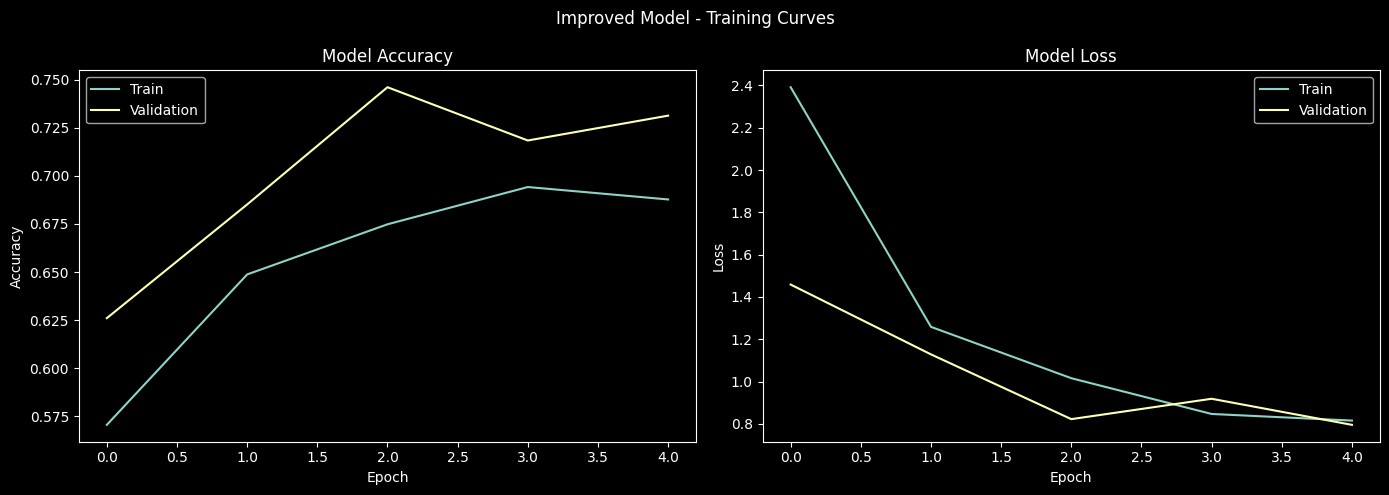

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_imp.history['accuracy'], label='Train')
axes[0].plot(history_imp.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_imp.history['loss'], label='Train')
axes[1].plot(history_imp.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Improved Model - Training Curves')
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

   BACTERIAL       0.72      0.80      0.76       184
      NORMAL       0.85      0.96      0.90       122
       VIRAL       0.69      0.50      0.58       131

    accuracy                           0.76       437
   macro avg       0.75      0.75      0.75       437
weighted avg       0.75      0.76      0.75       437



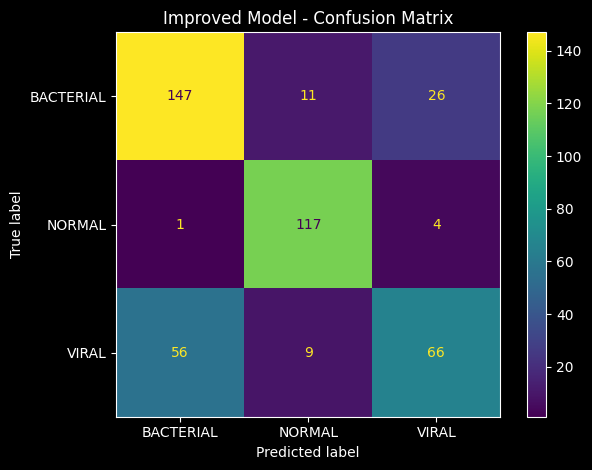

In [51]:
y_true_imp, y_pred_imp = [], []
for images, labels in test_ds:
    preds = improved_model.predict(images, verbose=0)
    y_pred_imp.extend(np.argmax(preds, axis=1))
    y_true_imp.extend(labels.numpy())

print(classification_report(y_true_imp, y_pred_imp, target_names=class_names))

ConfusionMatrixDisplay.from_predictions(y_true_imp, y_pred_imp, display_labels=class_names)
plt.title('Improved Model - Confusion Matrix')
plt.tight_layout()
plt.show()

---
## 12. Hyperparameter Search (Q5)

Keras Tuner RandomSearch over filter sizes, dense units and dropout — retains augmentation and class weights from previous improvements.

In [16]:
def build_tuned_model(hp):
    filters_1 = hp.Choice('filters_1', [8, 16, 32]) # best: 16
    filters_2 = hp.Choice('filters_2', [64, 128, 256])  # best: 128
    dense_units = hp.Choice('dense_units', [256, 512, 1024])  # best: 512
    dropout_rate = hp.Float('dropout', 0.2, 0.5, step=0.1)  # best: 0.4
    lr = hp.Choice('learning_rate', [0.0001, 0.0003, 0.001])  # best: 0.0003

    model = tf.keras.models.Sequential([
        RandomFlip('horizontal'),
        RandomRotation(0.1),
        RandomZoom(0.1),
        Rescaling(1.0 / 255),
        Conv2D(filters_1, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(filters_2, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(filters_2, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Flatten(),
        # GlobalAveragePooling2D(),
        Dense(dense_units, activation='relu'),
        Dropout(dropout_rate),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(lr),
        metrics=['accuracy']
    )
    return model


tuner = kt.RandomSearch(
    build_tuned_model,
    objective='val_accuracy',
    max_trials=10,
    seed=SEED,
    directory='kt_dir',
    project_name='pneumonia_v2',
    overwrite=False
)

tuner.search(train_ds, validation_data=val_ds, epochs=3, class_weight=class_weights, verbose=1)

best_hp = tuner.get_best_hyperparameters()[0]
print('Best hyperparameters:', best_hp.values)

Reloading Tuner from kt_dir/pneumonia_v2/tuner0.json
Best hyperparameters: {'filters_1': 16, 'filters_2': 128, 'dense_units': 512, 'dropout': 0.4, 'learning_rate': 0.0003}


In [17]:
# Train best model for full 8 epochs with class weights
tuned_model = tuner.hypermodel.build(best_hp)

save_callback_tuned = tf.keras.callbacks.ModelCheckpoint(
    'pneumonia_tuned.keras',
    save_best_only=True
)

start_time = time.time()

history_tuned = tuned_model.fit(
    train_ds,
    validation_data=val_ds,
    callbacks=[save_callback_tuned],
    class_weight=class_weights,
    epochs=EPOCHS
)

elapsed = time.time() - start_time
print(f'\nTraining time: {elapsed:.1f} seconds ({elapsed / 60:.1f} minutes)')

Epoch 1/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 35s 95ms/step - accuracy: 0.4806 - loss: 1.1357 - val_accuracy: 0.6990 - val_loss: 0.7042
Epoch 2/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 35s 98ms/step - accuracy: 0.6268 - loss: 0.9711 - val_accuracy: 0.6944 - val_loss: 0.6865
Epoch 3/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 36s 98ms/step - accuracy: 0.6665 - loss: 0.9166 - val_accuracy: 0.7572 - val_loss: 0.6177
Epoch 4/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 38s 104ms/step - accuracy: 0.6946 - loss: 0.8649 - val_accuracy: 0.7433 - val_loss: 0.6021
Epoch 5/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 38s 106ms/step - accuracy: 0.7032 - loss: 0.8433 - val_accuracy: 0.7442 - val_loss: 0.6074
Epoch 6/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 38s 106ms/step - accuracy: 0.7196 - loss: 0.8113 - val_accuracy: 0.7738 - val_loss: 0.5553
Epoch 7/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 38s 105ms/step - accuracy: 0.7212 - loss: 0.8021 - val_accuracy: 0.7655 - val_loss: 0.5467
Epoch 8/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 39s 106ms/step - accuracy: 0.7246 - loss: 0.7973 - val

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7849 - loss: 0.5286
Test loss:     0.5286
Test accuracy: 0.7849


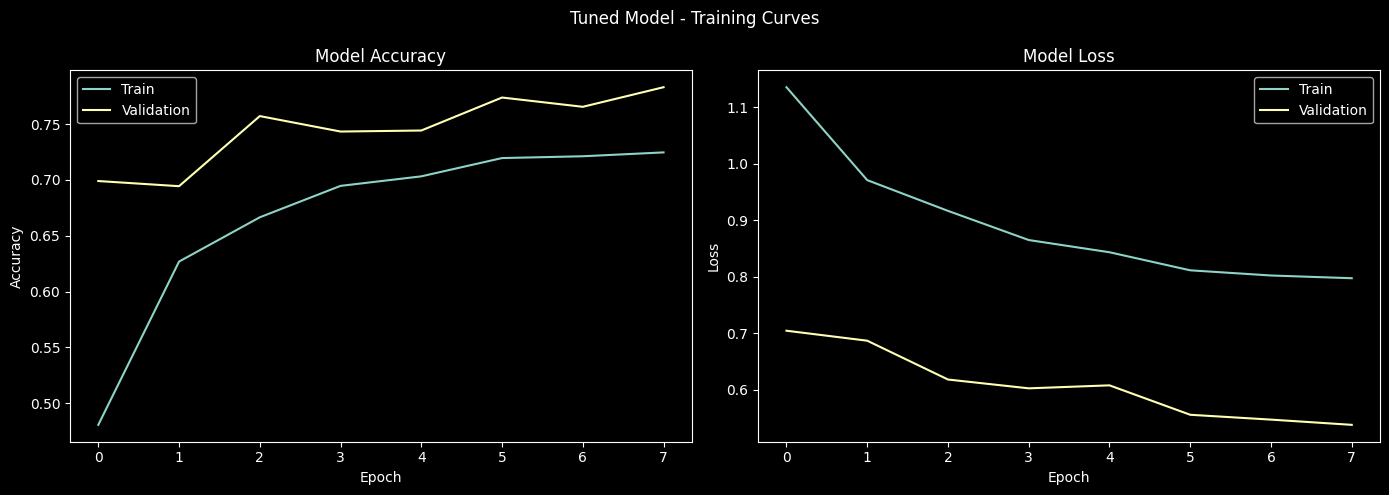

              precision    recall  f1-score   support

   BACTERIAL       0.78      0.79      0.79       184
      NORMAL       0.87      0.95      0.91       122
       VIRAL       0.70      0.62      0.66       131

    accuracy                           0.78       437
   macro avg       0.78      0.79      0.78       437
weighted avg       0.78      0.78      0.78       437



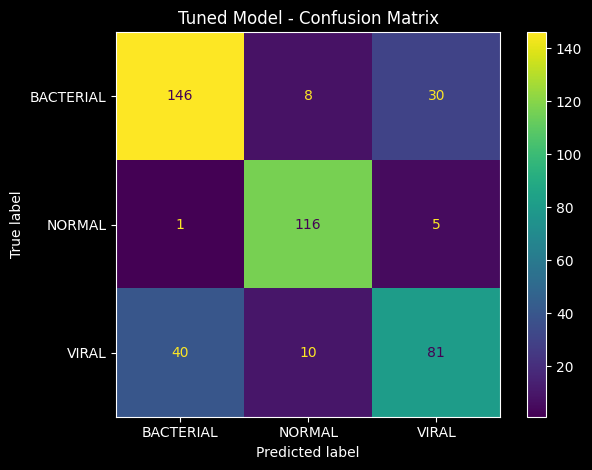

In [18]:
score_tuned = tuned_model.evaluate(test_ds)
print(f'Test loss:     {score_tuned[0]:.4f}')
print(f'Test accuracy: {score_tuned[1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_tuned.history['accuracy'], label='Train')
axes[0].plot(history_tuned.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[1].plot(history_tuned.history['loss'], label='Train')
axes[1].plot(history_tuned.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
plt.suptitle('Tuned Model - Training Curves')
plt.tight_layout()
plt.show()

y_true_tuned, y_pred_tuned = [], []
for images, labels in test_ds:
    preds = tuned_model.predict(images, verbose=0)
    y_pred_tuned.extend(np.argmax(preds, axis=1))
    y_true_tuned.extend(labels.numpy())

print(classification_report(y_true_tuned, y_pred_tuned, target_names=class_names))

ConfusionMatrixDisplay.from_predictions(y_true_tuned, y_pred_tuned, display_labels=class_names)
plt.title('Tuned Model - Confusion Matrix')
plt.tight_layout()
plt.show()

---
## 13. GradCAM Visualisation (Q9)

Gradient-weighted Class Activation Maps highlight which regions of the X-ray most influenced each prediction.

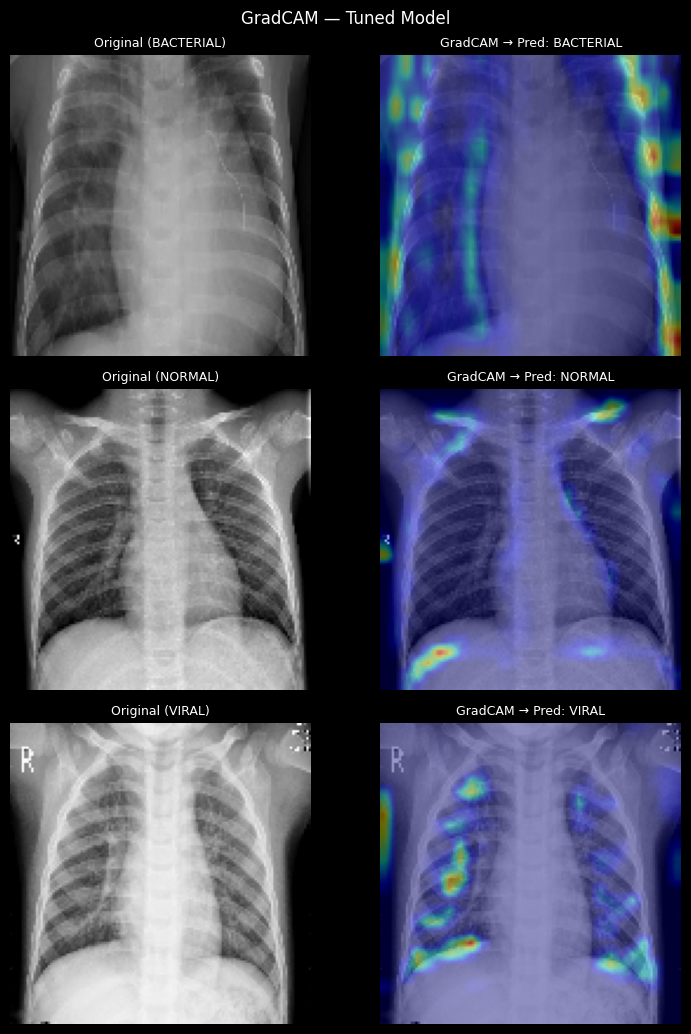

In [32]:
def make_gradcam_heatmap(img_array, model):
    # Build functional sub-model by tracing through layers (Keras 3 compatible)
    last_conv_idx = max(i for i, l in enumerate(model.layers) if isinstance(l, Conv2D))
    inp = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    x = inp
    conv_out = None
    for i, layer in enumerate(model.layers):
        x = layer(x)
        if i == last_conv_idx:
            conv_out = x
    grad_model = tf.keras.Model(inputs=inp, outputs=[conv_out, x])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)
        pred_class = tf.argmax(predictions[0])
        class_score = predictions[:, pred_class]
    grads = tape.gradient(class_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_class)


def overlay_heatmap(img, heatmap, alpha=0.4):
    heatmap_resized = np.array(
        tf.image.resize(heatmap[..., tf.newaxis], (img.shape[0], img.shape[1]))
    ).squeeze()
    heatmap_colored = plt.cm.jet(heatmap_resized)[:, :, :3]
    img_norm = img.astype(np.float32) / 255.0
    return np.clip(img_norm * (1 - alpha) + heatmap_colored * alpha, 0, 1)


# Collect one sample image per class from the test set
samples = {}
for images, labels in test_ds:
    for img, label in zip(images.numpy(), labels.numpy()):
        cls = class_names[label]
        if cls not in samples:
            samples[cls] = img
        if len(samples) == num_classes:
            break
    if len(samples) == num_classes:
        break

# Plot GradCAM for each class
fig, axes = plt.subplots(num_classes, 2, figsize=(8, num_classes * 3.5))
for row, cls in enumerate(class_names):
    img = samples[cls]
    img_tensor = tf.expand_dims(img, axis=0)
    heatmap, pred_idx = make_gradcam_heatmap(img_tensor, tuned_model)
    overlay = overlay_heatmap(img, heatmap)

    axes[row, 0].imshow(img.astype('uint8'))
    axes[row, 0].set_title(f'Original ({cls})', fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(overlay)
    axes[row, 1].set_title(f'GradCAM → Pred: {class_names[pred_idx]}', fontsize=9)
    axes[row, 1].axis('off')

plt.suptitle('GradCAM — Tuned Model', fontsize=12)
plt.tight_layout()
plt.show()